In [13]:
import numpy as np
import matplotlib.pyplot as plt

def my_least_squares(x, y):
    n = len(x)
    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_xy = np.sum(x*y)
    sum_x2 = np.sum(x**2)
    m = ((n * sum_xy) - (sum_x * sum_y)) / ((n * sum_x2) - sum_x**2)
    b = (sum_y - (m * sum_x)) / n
    return m, b

x_test = np.random.uniform(-1, 1, 5)
y_test = np.random.uniform(-1, 1, 5)

idx = np.argsort(x_test)
x_test = x_test[idx]
y_test = y_test[idx]

m_test, b_test = my_least_squares(x_test, y_test)
A_test = np.vstack([x_test, np.ones(len(x_test))]).T
m_np_test, b_np_test = np.linalg.lstsq(A_test, y_test, rcond=None)[0]

print(f"My method: y = {m_test}x + {b_test}")
print(f"Numpy method: y = {m_np_test}x + {b_np_test}")


My method: y = -0.33598229744848357x + -0.20746205570164275
Numpy method: y = -0.33598229744848385x + -0.2074620557016428


In [14]:
x = np.arange(0, 1, 0.01)

m_original = 6
b_original = 4

perturbation = np.random.uniform(0, 1, len(x))
sign = np.random.choice([-1, 1], len(x))
y = m_original * x + b_original + sign * perturbation

m_my, b_my = my_least_squares(x, y)
A = np.vstack([x, np.ones(len(x))]).T
m_np, b_np = np.linalg.lstsq(A, y, rcond=None)[0]

print(f"My method: y = {m_my}x + {b_my}")
print(f"Numpy method: y = {m_np}x + {b_np}")

predicted_y = m_my * x + b_my
residuals = y - predicted_y

print(f"\nResiduals: {residuals}")

largest = np.argmax(np.abs(residuals))
smallest = np.argmin(np.abs(residuals))

print("\nLargest residual error:")
print(f"x = {x[largest]}, y = {y[largest]}, residual = {residuals[largest]}")

print("\nSmallest residual error:")
print(f"x = {x[smallest]}, y = {y[smallest]}, residual = {residuals[smallest]}")

My method: y = 5.973539778742346x + 3.936133389060067
Numpy method: y = 5.9735397787423565x + 3.936133389060059

Residuals: [ 0.02783307  0.54432691 -0.04032461 -0.70005627 -0.0285945  -0.22261897
 -0.40209449 -0.66960662  0.05456546 -0.33503847 -0.34382549  0.27561788
 -0.39510004 -0.42281014  0.29297761 -0.51489723  0.62082047 -0.0536157
  1.0173519  -0.91322729  0.25384192  1.03740731 -0.0610839  -0.1811701
 -0.08990684  0.82669612 -0.16709244 -0.61493871  0.81207997  0.07206915
  0.96599445  0.81649031  0.25505666 -0.88043416 -0.19056638 -0.28850138
  0.63192427  0.55128676  0.87609207 -0.65602129 -0.23369497  0.19296689
  0.09513221 -0.71360857 -0.92297752  0.68446139  0.38137648  0.11492695
  0.11356319  0.44743207  0.79352459 -0.60871554  0.40073824 -0.07249062
 -0.0294074  -0.64749793 -0.42155907 -0.82581306 -0.40669663  0.49694965
 -0.70993544  0.17960348 -0.561033   -0.17235551 -0.19192041  1.04673081
  1.03514061  0.35747023 -0.66476998  0.22042149 -0.23233773 -0.03261519
  

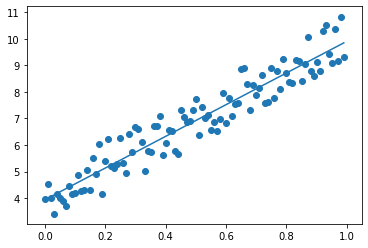

In [15]:
plt.scatter(x, y)
plt.plot(x, predicted_y)
plt.show()